In [1]:
from transformers import TFBertForSequenceClassification
model = TFBertForSequenceClassification.from_pretrained("/Users/Amruta/Downloads/bert_model")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-25 16:21:35.702839: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-02-25 16:21:35.702870: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-02-25 16:21:35.702873: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-02-25 16:21:35.703107: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-02-25 16:21:35.703119: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:

In [2]:
import pandas as pd
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_test = pd.read_csv("/Users/Amruta/Downloads/bertTest.csv")
print(df_test.head())

                                                text  label
0  Contrary to other reviews, I have zero complai...      1
1  Last summer I had an appointment to get new ti...      0
2  Friendly staff, same starbucks fair you get an...      1
3  The food is good. Unfortunately the service is...      0
4  Even when we didn't have a car Filene's Baseme...      1


In [6]:
# Tokenize the test text data
import transformers
tokenizer = transformers.BertTokenizer.from_pretrained("bert-base-uncased")
test_encodings = tokenizer(
    df_test["text"].tolist(),  # Convert text column to list
    truncation=True,
    padding=True,
    max_length=128,  # Adjust max_length as needed
    return_tensors="tf"
)

In [ ]:
import tensorflow as tf

batch_size = 16  # Try reducing to 8 or even 4 if necessary

# Use TensorFlow Dataset API to handle batches efficiently
test_dataset = tf.data.Dataset.from_tensor_slices(dict(test_encodings)).batch(batch_size)

# Run inference in smaller batches
predictions = []
for batch in test_dataset:
    outputs = model(batch)  
    probs = tf.nn.softmax(outputs.logits, axis=-1)
    batch_preds = tf.argmax(probs, axis=1).numpy()
    predictions.extend(batch_preds)  



2025-02-25 17:02:09.690109: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
print(predictions)

[1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 

In [9]:
import numpy as np

true_labels = np.array(df_test["label"])
predicted_labels = np.array(predictions)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Model Accuracy: {accuracy:.4f}")



Model Accuracy: 0.9438


In [15]:
preds_short = [1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0]
#print(df_test["label"][:len(preds_short)])
print(len(df_test["text"]))

for i in range(len(preds_short)):
    if preds_short[i] != df_test["label"][i]:
        print(df_test["text"][i] + "\n")

38000
I don't know, maybe I'm not clear on the concept of Whole Foods.  Don't get me wrong, there's nothing really wrong with shopping at Whole Foods.  Whole Foods does have wonderful merchandise, but...\n\nI have found that I can buy a lot of the same organic things and environmentally safe cleaners at Giant Eagle for less.\n\nThier wine and beer selection, supposedly quite remarkable in other states, well remember, this is Pennsylvania.  You can't buy those things at the grocery store.  \n\nI can get just as good quality meat and produce in the Strip District.  Sometimes, even better quality.\n\nI guess the benefit of Whole Foods  is that you can find a lot under one roof and don't have to spend a lot of time and gas going to different stores.  I'm not slamming Whole Foods at all, but I actually like Trader Joe's better.

And so....the search for a new hair salon continues. Sigh. Don't get me wrong, the cut was a good cut. The salon itself was clean and stylish. The owner, welcoming 

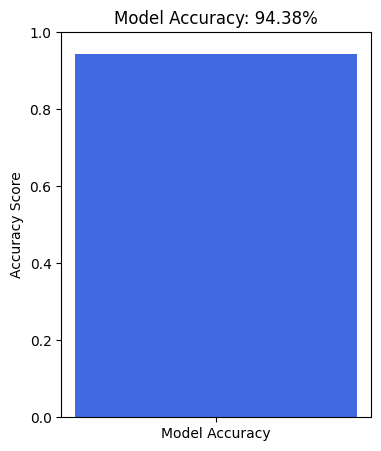

In [14]:


accuracy = accuracy_score(true_labels, predicted_labels)

plt.figure(figsize=(4, 5))
plt.bar(["Model Accuracy"], [accuracy], color="royalblue")
plt.ylim(0, 1)
plt.ylabel("Accuracy Score")
plt.title(f"Model Accuracy: {accuracy:.2%}")
plt.show()


Confusion Matrix:
 [[18054   946]
 [ 1188 17812]]
Note: you may need to restart the kernel to use updated packages.


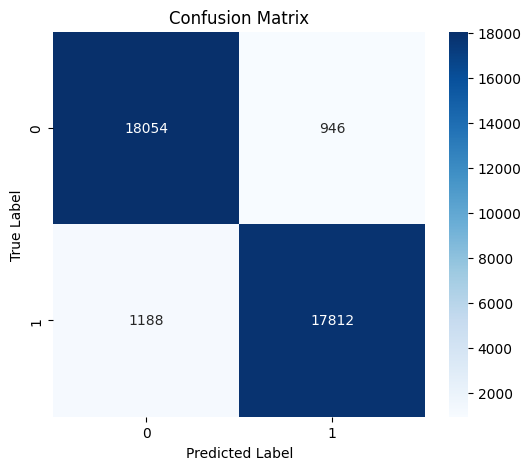

In [13]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:\n", conf_matrix)

%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


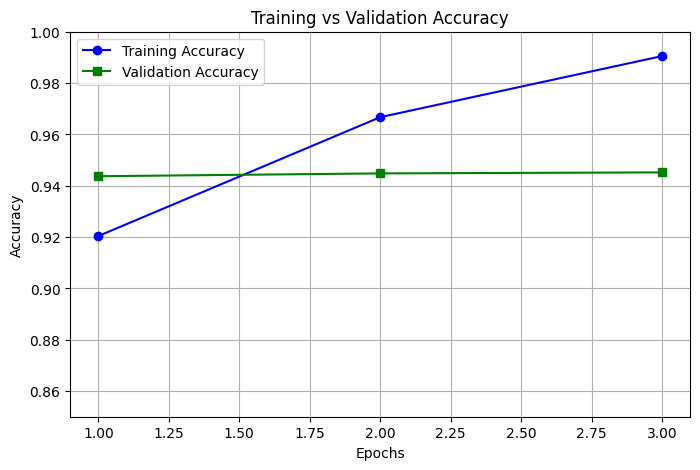

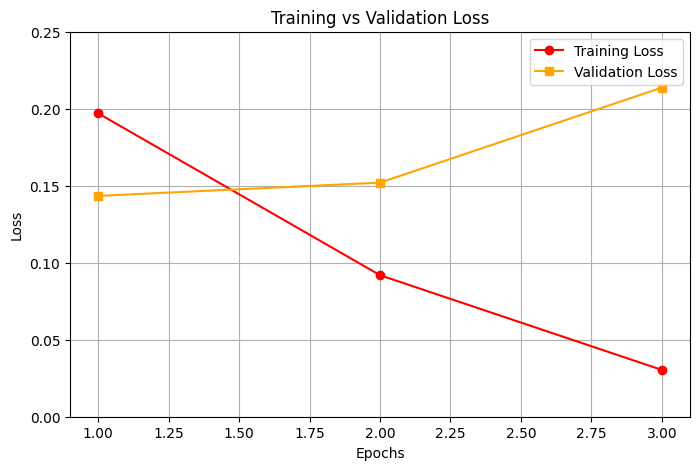

In [17]:
epochs = [1, 2, 3]
accuracy = [0.9204, 0.9667, 0.9905]
val_accuracy = [0.9437, 0.9448, 0.9452]
loss = [0.1970, 0.0919, 0.0304]
val_loss = [0.1434, 0.1520, 0.2137]

# Accuracy and Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, marker="o", label="Training Accuracy", color="blue")
plt.plot(epochs, val_accuracy, marker="s", label="Validation Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.ylim(0.85, 1)  # Adjust based on range
plt.grid()
plt.show()

# Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, marker="o", label="Training Loss", color="red")
plt.plot(epochs, val_loss, marker="s", label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.ylim(0, 0.25)  # Adjust based on range
plt.grid()
plt.show()
